In [10]:
#Aynı modeli tek katmanlı sinir ağıyla kur: one-hot input, 27x27 weight matrix, softmax, NLL loss, gradient descent döngüsü. 
#Loss'un görev 3'teki sayım modelinin loss'una yaklaştığını göster. 
#Buradaki backward() geçen hafta micrograd'da kendi yazdığın mekanizmanın aynısı. 

In [11]:
#core
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


In [12]:
import torch
import torch.nn.functional as F
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()

In [13]:
# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [14]:
losses = []
for i in range(101):
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
    loss = -probs[torch.arange(num), ys].log().mean() 
    losses.append(loss.item())
    
    # backward pass
    W.grad = None # set to zero the gradient
    loss.backward()
    
    if i % 20 == 0: #first and every 20th iterations print.     
        print(f"step {i}: loss = {loss.item()}")
    
    # update
    W.data += -50 * W.grad


step 0: loss = 3.758953094482422
step 20: loss = 2.572789192199707
step 40: loss = 2.5086867809295654
step 60: loss = 2.488049268722534
step 80: loss = 2.478290319442749
step 100: loss = 2.4726526737213135


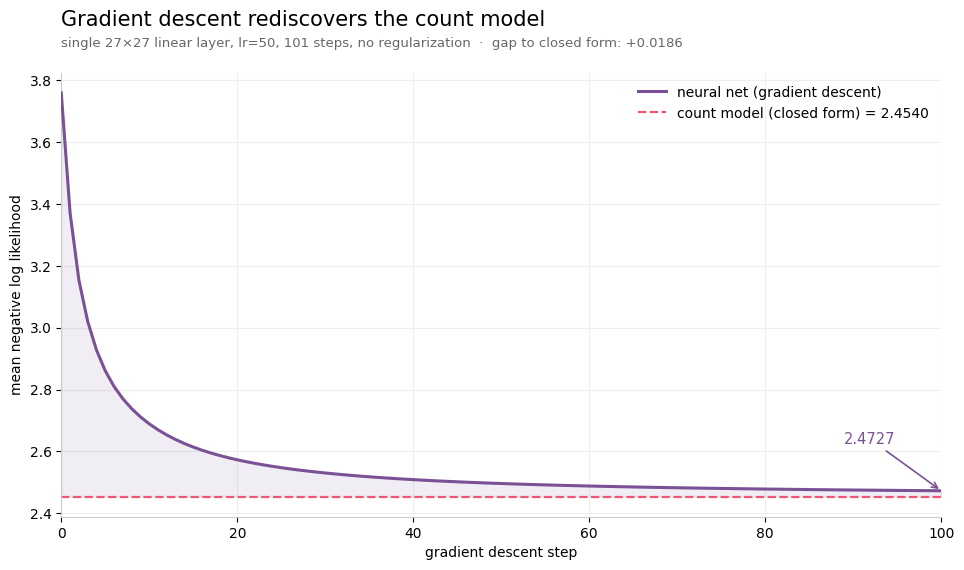

In [15]:
import matplotlib.pyplot as plt

N = torch.zeros(27, 27, dtype=torch.int32)
for w in words:
    chs = ['.'] + list(w) + ['.']
    for a, b in zip(chs, chs[1:]):
        N[stoi[a], stoi[b]] += 1
Pc = N.float(); Pc = Pc / Pc.sum(1, keepdims=True)
target = -Pc[xs, ys].log().mean().item()

plt.rcParams.update({"font.size": 10})
fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(left=.09, right=.97, top=.85, bottom=.11)

ax.plot(losses, color="#7a5195", linewidth=2.2, zorder=3, label="neural net (gradient descent)")
ax.axhline(target, color="#ef5675", linestyle="--", linewidth=1.6, zorder=2,
           label=f"count model (closed form) = {target:.4f}")
ax.fill_between(range(len(losses)), target, losses, color="#7a5195", alpha=.10, zorder=1)

ax.set_xlabel("gradient descent step")
ax.set_ylabel("mean negative log likelihood")
ax.set_xlim(0, len(losses)-1)
ax.grid(color="#eeeeee", zorder=0); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
for s in ("left", "bottom"): ax.spines[s].set_color("#cccccc")
ax.legend(frameon=False, loc="upper right", fontsize=10)

ax.annotate(f"{losses[-1]:.4f}", xy=(len(losses)-1, losses[-1]),
            xytext=(-70, 34), textcoords="offset points", fontsize=10.5, color="#7a5195",
            arrowprops=dict(arrowstyle="->", color="#7a5195", lw=1.2))

fig.suptitle("Gradient descent rediscovers the count model", x=.09, ha="left", fontsize=15, y=.955)
fig.text(.09, .893, f"single 27×27 linear layer, lr=50, {len(losses)} steps, no regularization  ·  "
                    f"gap to closed form: {losses[-1]-target:+.4f}", fontsize=9.5, color="#666");